---
# DNN : `Ozone`
---

## Packages

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras import callbacks, layers, models

import matplotlib.pyplot as plt

2025-10-01 15:12:21.431494: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 15:12:21.496711: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-01 15:12:23.063636: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 1. Données
---

### 1.1. Importation

In [2]:
# En local :
directory = 'data/'

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
# from google.colab import drive
# drive.mount('/content/drive')
# directory = '/content/drive/MyDrive/Data/'

In [3]:
data = pd.read_csv(directory + 'ozone_complet.csv',
                   header    = 0,
                   # index_col = 0,
                   sep       = ';',
                   decimal   = ',')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1464 entries, 0 to 1463
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1464 non-null   int64  
 1   maxO3   1391 non-null   float64
 2   T6      1463 non-null   float64
 3   T9      1463 non-null   float64
 4   T12     1463 non-null   float64
 5   T15     1463 non-null   float64
 6   T18     1463 non-null   float64
 7   Ne6     1462 non-null   float64
 8   Ne9     1462 non-null   float64
 9   Ne12    1462 non-null   float64
 10  Ne15    1462 non-null   float64
 11  Ne18    1459 non-null   float64
 12  Vdir6   1463 non-null   float64
 13  Vvit6   1463 non-null   float64
 14  Vdir9   1463 non-null   float64
 15  Vvit9   1463 non-null   float64
 16  Vdir12  1463 non-null   float64
 17  Vvit12  1463 non-null   float64
 18  Vdir15  1463 non-null   float64
 19  Vvit15  1463 non-null   float64
 20  Vdir18  1463 non-null   float64
 21  Vvit18  1463 non-null   float64
 22  

In [5]:
data.head()

,date,maxO3,T6,T9,T12,T15,T18,Ne6,Ne9,Ne12,...,Vdir9,Vvit9,Vdir12,Vvit12,Vdir15,Vvit15,Vdir18,Vvit18,Vx,maxO3v
0,19950401,47.6,10.1,11.6,13.3,13.6,12.2,8.0,8.0,8.0,...,290.0,4.0,300.0,4.0,340.0,4.0,20.0,4.0,-3.4641,62.2
1,19950402,56.2,9.5,9.4,13.8,17.4,16.3,8.0,8.0,7.0,...,160.0,2.0,180.0,3.0,110.0,1.0,350.0,2.0,0.0000,47.6
2,19950403,61.8,3.6,8.0,16.8,21.5,20.2,4.0,5.0,2.0,...,20.0,2.0,340.0,1.0,170.0,2.0,170.0,3.0,-0.3420,56.2
3,19950404,50.8,9.5,10.5,11.4,12.2,11.4,8.0,7.0,7.0,...,10.0,4.0,350.0,3.0,350.0,3.0,350.0,4.0,-0.5209,61.8
4,19950405,59.8,9.8,10.8,13.8,14.3,13.3,8.0,7.0,8.0,...,340.0,2.0,280.0,1.0,320.0,3.0,350.0,4.0,-0.9848,50.8


### 1.2. Gestion des données manquantes

In [6]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
maxO3     4.986339
maxO3v    4.986339
Ne18      0.341530
Ne9       0.136612
Ne12      0.136612
Ne6       0.136612
Ne15      0.136612
T18       0.068306
T15       0.068306
T12       0.068306
T9        0.068306
T6        0.068306
Vdir6     0.068306
Vdir9     0.068306
Vvit6     0.068306
Vvit9     0.068306
Vdir12    0.068306
Vdir15    0.068306
Vvit12    0.068306
Vvit15    0.068306
Vdir18    0.068306
Vvit18    0.068306
Vx        0.068306
dtype: float64


In [7]:
data.dropna(inplace=True)

### 1.3. Gestion des variables

In [8]:
target = 'maxO3'

y = data[target]
X = data.drop(target, axis=1)

### 1.4. Création des échantillons de validation et test

In [9]:
test_portion  = 1/5
valid_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (873, 23)
Dimensions de X_valid : (219, 23)
Dimensions de X_test  : (274, 23)
Dimensions de y_train : (873,)
Dimensions de y_valid : (219,)
Dimensions de y_test  : (274,)


### 1.5. Normalisation des covariables

In [10]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_norm = scaler.transform(X_train)
X_valid_norm = scaler.transform(X_valid)
X_test_norm  = scaler.transform(X_test)

---
## 2. DNN
---

### 2.1. Architecture

In [11]:
dim_inputs  = (X_train_norm.shape[1],)
dim_outputs = 1

n_units_hl1 = 50
n_units_hl2 = 30

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_Hidden_layer_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_Hidden_layer_2'))

model.add(layers.Dense(units=dim_outputs, activation='linear', name='Output_layer'))

model.summary()

2025-10-01 15:12:23.788695: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_layer_1 (Dense)          │ (None, 50)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_1          │ (None, 50)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_2          │ (None, 30)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,761 (10.79 KB)

 Trainable params: 2,761 (10.79 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [12]:
model.compile(optimizer = 'adam',
              loss      = 'mse',
              metrics   = ['mae'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 20,
                                   restore_best_weights = True)

In [13]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 160,
                 epochs          = 200,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 7851.7397 - mae: 85.4946 - val_loss: 7165.2632 - val_mae: 81.8627
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 7757.2661 - mae: 84.9696 - val_loss: 7073.3174 - val_mae: 81.3305
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 7653.2188 - mae: 84.3988 - val_loss: 6978.2725 - val_mae: 80.7788
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7548.8750 - mae: 83.8146 - val_loss: 6875.1494 - val_mae: 80.1794
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 7434.4678 - mae: 83.1826 - val_loss: 6760.7715 - val_mae: 79.5105
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 7299.1396 - mae: 82.4280 - val_loss: 6631.4473 - val_mae: 78.7457
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 7159.0361 - mae: 81.6295 - val_loss: 6484.3413 - val_mae: 77.8673
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 6978.3721 - mae: 80.6138 - val_loss: 6312.8779 - val_mae: 76.8329
Epoch 9/

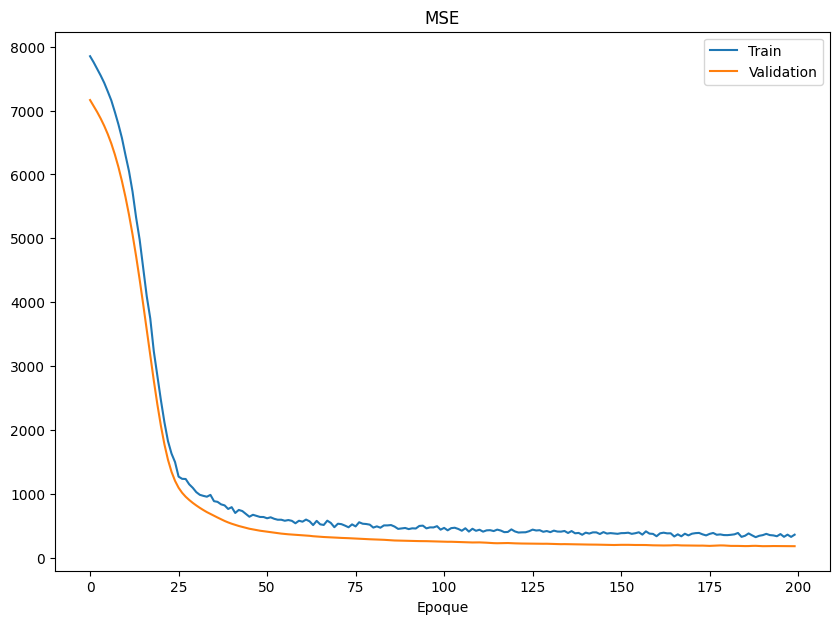

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(hist.history['loss'], label='Train')
ax.plot(hist.history['val_loss'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('MSE')
ax.legend(loc='best')
plt.show()

### 2.4. Prévisions

In [15]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


array([[ 78.45054],
       [ 75.09437],
       [106.723  ],
       [ 85.43526],
       [ 69.40637]], dtype=float32)

In [16]:
y_test_pred_classes = (y_test_pred > 0.5).astype(int)
y_test_pred_classes[0:5]

array([[1],
       [1],
       [1],
       [1],
       [1]])

In [20]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'mse test   : {score_test[0]:4.4f}')
print(f'mae test : {score_test[1]:4.4f}')

mse test   : 225.5046
mae test : 12.0486
